In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
IMG_SIZE =224
BATCH_SIZE=32

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [4]:
train_generator = train_datagen.flow_from_directroy('/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/Cataract Detection/Train',
                                                    target_size=(IMG_SIZE,IMG_SIZE),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='binary',
                                                    subset='training')

Found 1069 images belonging to 2 classes.


In [5]:
val_generator = train_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/Cataract Detection/Train',
                                                    target_size=(IMG_SIZE,IMG_SIZE),
                                                    batch_size=BATCH_SIZE,
                                                    class_mode='binary',
                                                    subset='validation')

Found 266 images belonging to 2 classes.


In [6]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(train_generator,validation_data=val_generator,batch_size=BATCH_SIZE,epochs=5)

Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 306s 9s/step - accuracy: 0.7942 - loss: 0.6325 - val_accuracy: 0.6541 - val_loss: 0.6426
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 411ms/step - accuracy: 0.9635 - loss: 0.1166 - val_accuracy: 0.9135 - val_loss: 0.1908
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 397ms/step - accuracy: 0.9832 - loss: 0.0457 - val_accuracy: 0.9850 - val_loss: 0.0695
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 401ms/step - accuracy: 0.9916 - loss: 0.0272 - val_accuracy: 0.9887 - val_loss: 0.0267
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 394ms/step - accuracy: 0.9972 - loss: 0.0114 - val_accuracy: 0.9925 - val_loss: 0.0156


In [9]:
model.save('/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/Cataract Detection/CataractDetection.h5')

In [10]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

In [11]:
model=load_model('/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/Cataract Detection/CataractDetection.h5')
print("Model Loaded")

Model Loaded


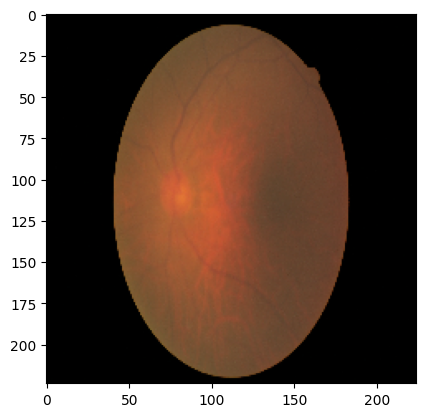

In [12]:
test_image_path="/content/drive/MyDrive/Colab Notebooks/Comptia/Project01/Cataract Detection/Test/yes/cataract_087.png"
img=image.load_img(test_image_path,target_size=(224,224))
plt.imshow(img)
plt.axis()
plt.show()

In [13]:
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array /= 225.

prediction =  model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
[[1.]]


In [14]:
if prediction >= 0.5:
  print("You have Cataract")
else:
  print("You don't have Cataract")

You have Cataract
